# 🌍 AQI Prediction using Multiple Linear Regression

## ⚠️Problem Statement

Air pollution is one of the major environmental issues affecting human health worldwide. 
The Air Quality Index (AQI) is a standardized measure used to indicate the level of air pollution.

Predicting AQI based on pollutant concentrations and weather conditions can help authorities and 
citizens take preventive measures and improve environmental monitoring.

## 🎯 Goal

To develop a machine learning model that accurately predicts the Air Quality Index (AQI) using pollutant concentrations and weather-related factors.

## 📌 Project Objectives

• 📊 Perform exploratory data analysis to understand the structure and patterns in the air quality dataset.

• 🧹 Clean and preprocess the dataset by handling missing values, outliers, and inconsistencies.

• 🔍 Analyze the relationship between pollutant levels, weather conditions, and AQI.

• 🤖 Train a machine learning model to predict AQI based on environmental features.

• 📈 Evaluate the model’s performance and extract insights about the key factors influencing air pollution.

In [567]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [568]:
sns.set_style("whitegrid")
plt.rcParams.update(plt.rcParamsDefault)

In [569]:
import warnings
warnings.filterwarnings("ignore")

## Load Dataset

In [570]:
df=pd.read_csv("../data/aqi_dataset.csv")

In [571]:
df.head()

,datetime,date,year,month,day,hour,day_of_week,is_weekend,season,city,...,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi,aqi_category
0,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,119.6,47.7,5.19,12.3,9.4,100,3.6,1.2,500,Severe
1,2020-01-01 12:00:00,2020-01-01,2020,1,1,12,Wednesday,0,winter,Delhi,...,117.9,39.3,4.32,15.8,20.6,50,5.9,1.4,500,Severe
2,2020-01-01 18:00:00,2020-01-01,2020,1,1,18,Wednesday,0,winter,Delhi,...,150.1,36.3,7.13,14.3,12.4,56,4.5,1.1,500,Severe
3,2020-01-01 23:00:00,2020-01-01,2020,1,1,23,Wednesday,0,winter,Delhi,...,142.0,30.3,4.90,13.2,14.4,48,5.8,1.4,500,Severe
4,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,138.4,41.5,7.56,15.4,6.8,100,2.8,0.4,500,Severe


## Dataset Overview

In [572]:
df.shape

(201664, 25)

In [573]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201664 entries, 0 to 201663
Data columns (total 25 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   datetime      201664 non-null  object 
 1   date          201664 non-null  object 
 2   year          201664 non-null  int64  
 3   month         201664 non-null  int64  
 4   day           201664 non-null  int64  
 5   hour          201664 non-null  int64  
 6   day_of_week   201664 non-null  object 
 7   is_weekend    201664 non-null  int64  
 8   season        201664 non-null  object 
 9   city          201664 non-null  object 
 10  station       201664 non-null  object 
 11  latitude      201664 non-null  float64
 12  longitude     201664 non-null  float64
 13  pm25          201664 non-null  float64
 14  pm10          201664 non-null  float64
 15  no2           201664 non-null  float64
 16  so2           201664 non-null  float64
 17  co            201664 non-null  float64
 18  o3  

In [574]:
df.describe()

,year,month,day,hour,is_weekend,latitude,longitude,pm25,pm10,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi
count,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000
mean,2022.499544,6.521898,15.732664,14.750000,0.285584,28.596791,77.208600,183.420341,348.567402,69.761495,16.028998,3.033964,27.185762,26.895227,61.041564,10.528524,5.007801,265.830148
std,1.708185,3.448995,8.801392,6.378691,0.451693,0.112215,0.125113,193.138161,370.016790,75.972086,17.201027,3.284094,13.569802,8.984843,24.737106,6.045043,3.685609,171.508950
min,2020.000000,1.000000,1.000000,6.000000,0.000000,28.372200,77.026600,15.000000,24.000000,8.000000,4.000000,0.300000,12.000000,6.000000,20.000000,2.100000,0.200000,25.000000
25%,2021.000000,4.000000,8.000000,10.500000,0.000000,28.530800,77.071200,55.300000,104.100000,19.900000,4.500000,0.870000,18.000000,19.900000,39.000000,5.900000,1.900000,103.000000
50%,2022.500000,7.000000,16.000000,15.000000,0.000000,28.624600,77.201000,99.500000,189.800000,38.300000,8.700000,1.690000,23.300000,27.600000,58.000000,9.200000,4.400000,232.000000
75%,2024.000000,10.000000,23.000000,19.250000,1.000000,28.668300,77.316400,254.700000,481.200000,94.000000,20.900000,4.120000,31.800000,33.500000,83.000000,14.200000,7.100000,464.000000
max,2025.000000,12.000000,31.000000,23.000000,1.000000,28.776200,77.504000,900.000000,1979.700000,593.500000,121.600000,22.670000,84.000000,44.800000,100.000000,31.500000,15.000000,500.000000


## Feature Selection
Removing unnecessary columns that are not required for model training.

In [575]:
df=df.drop(columns=["datetime","date","city","station","aqi_category"])

In [576]:
df["pm_ratio"] = df["pm25"] / (df["pm10"] + 1)

## Missingvalues Analysis

In [577]:
df.isnull().sum()

year           0
month          0
day            0
hour           0
day_of_week    0
is_weekend     0
season         0
latitude       0
longitude      0
pm25           0
pm10           0
no2            0
so2            0
co             0
o3             0
temperature    0
humidity       0
wind_speed     0
visibility     0
aqi            0
pm_ratio       0
dtype: int64

The dataset does not contain significant missing values, indicating good data quality.  
Since missing values are minimal, they can either be ignored or handled using simple imputation techniques if required during preprocessing.

## Duplicate Records Check

In [578]:
df.duplicated().sum()

np.int64(0)

## Outlier Detection

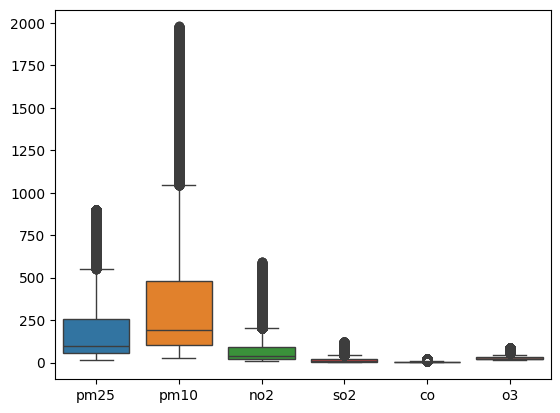

In [579]:
sns.boxplot(data=df[["pm25","pm10","no2","so2","co","o3"]])
plt.show()



The boxplots show the presence of several outliers in pollutant concentration features such as PM25 and PM10.  
These outliers may represent extreme pollution events, which are common in real-world environmental datasets.

Instead of removing them directly, they should be handled carefully since they may contain important information about severe pollution conditions.

In [580]:
columns= ["pm25","pm10","no2","so2","co","o3"]
for i in columns:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1
    minimum = Q1 - 1.5 * IQR
    maximum = Q3 + 1.5 * IQR
    df = df[(df[i] >= minimum) & (df[i] <= maximum)]

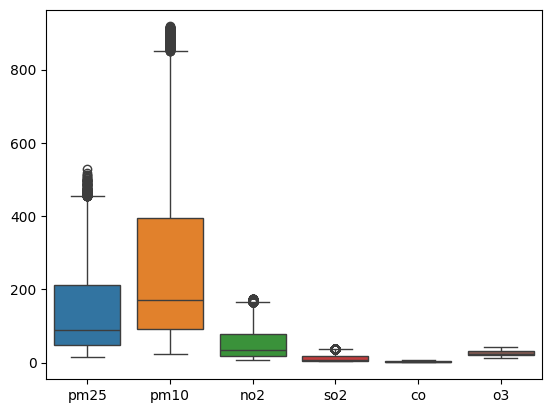

In [581]:
sns.boxplot(data=df[["pm25","pm10","no2","so2","co","o3"]])
plt.show()

In [582]:
df.shape

(164609, 21)

## Data Type Verification

In [583]:
df.dtypes

year             int64
month            int64
day              int64
hour             int64
day_of_week     object
is_weekend       int64
season          object
latitude       float64
longitude      float64
pm25           float64
pm10           float64
no2            float64
so2            float64
co             float64
o3             float64
temperature    float64
humidity         int64
wind_speed     float64
visibility     float64
aqi              int64
pm_ratio       float64
dtype: object

## 🔎 Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps in understanding the structure of the dataset and identifying patterns that influence AQI.

### Key Focus Areas

• 📉 Distribution of pollutant concentrations  
• 📊 Relationship between pollutants and AQI  
• 🌦️ Impact of weather conditions on air quality  
• 🕒 Variation of AQI across different months and hours  
• 🔗 Correlation between different environmental variables

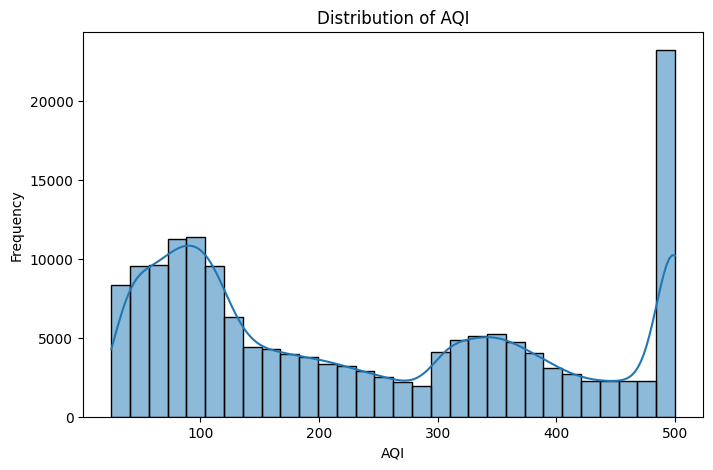

In [584]:
plt.figure(figsize=(8,5))
sns.histplot(df["aqi"], kde=True, bins=30)
plt.title("Distribution of AQI")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.show()

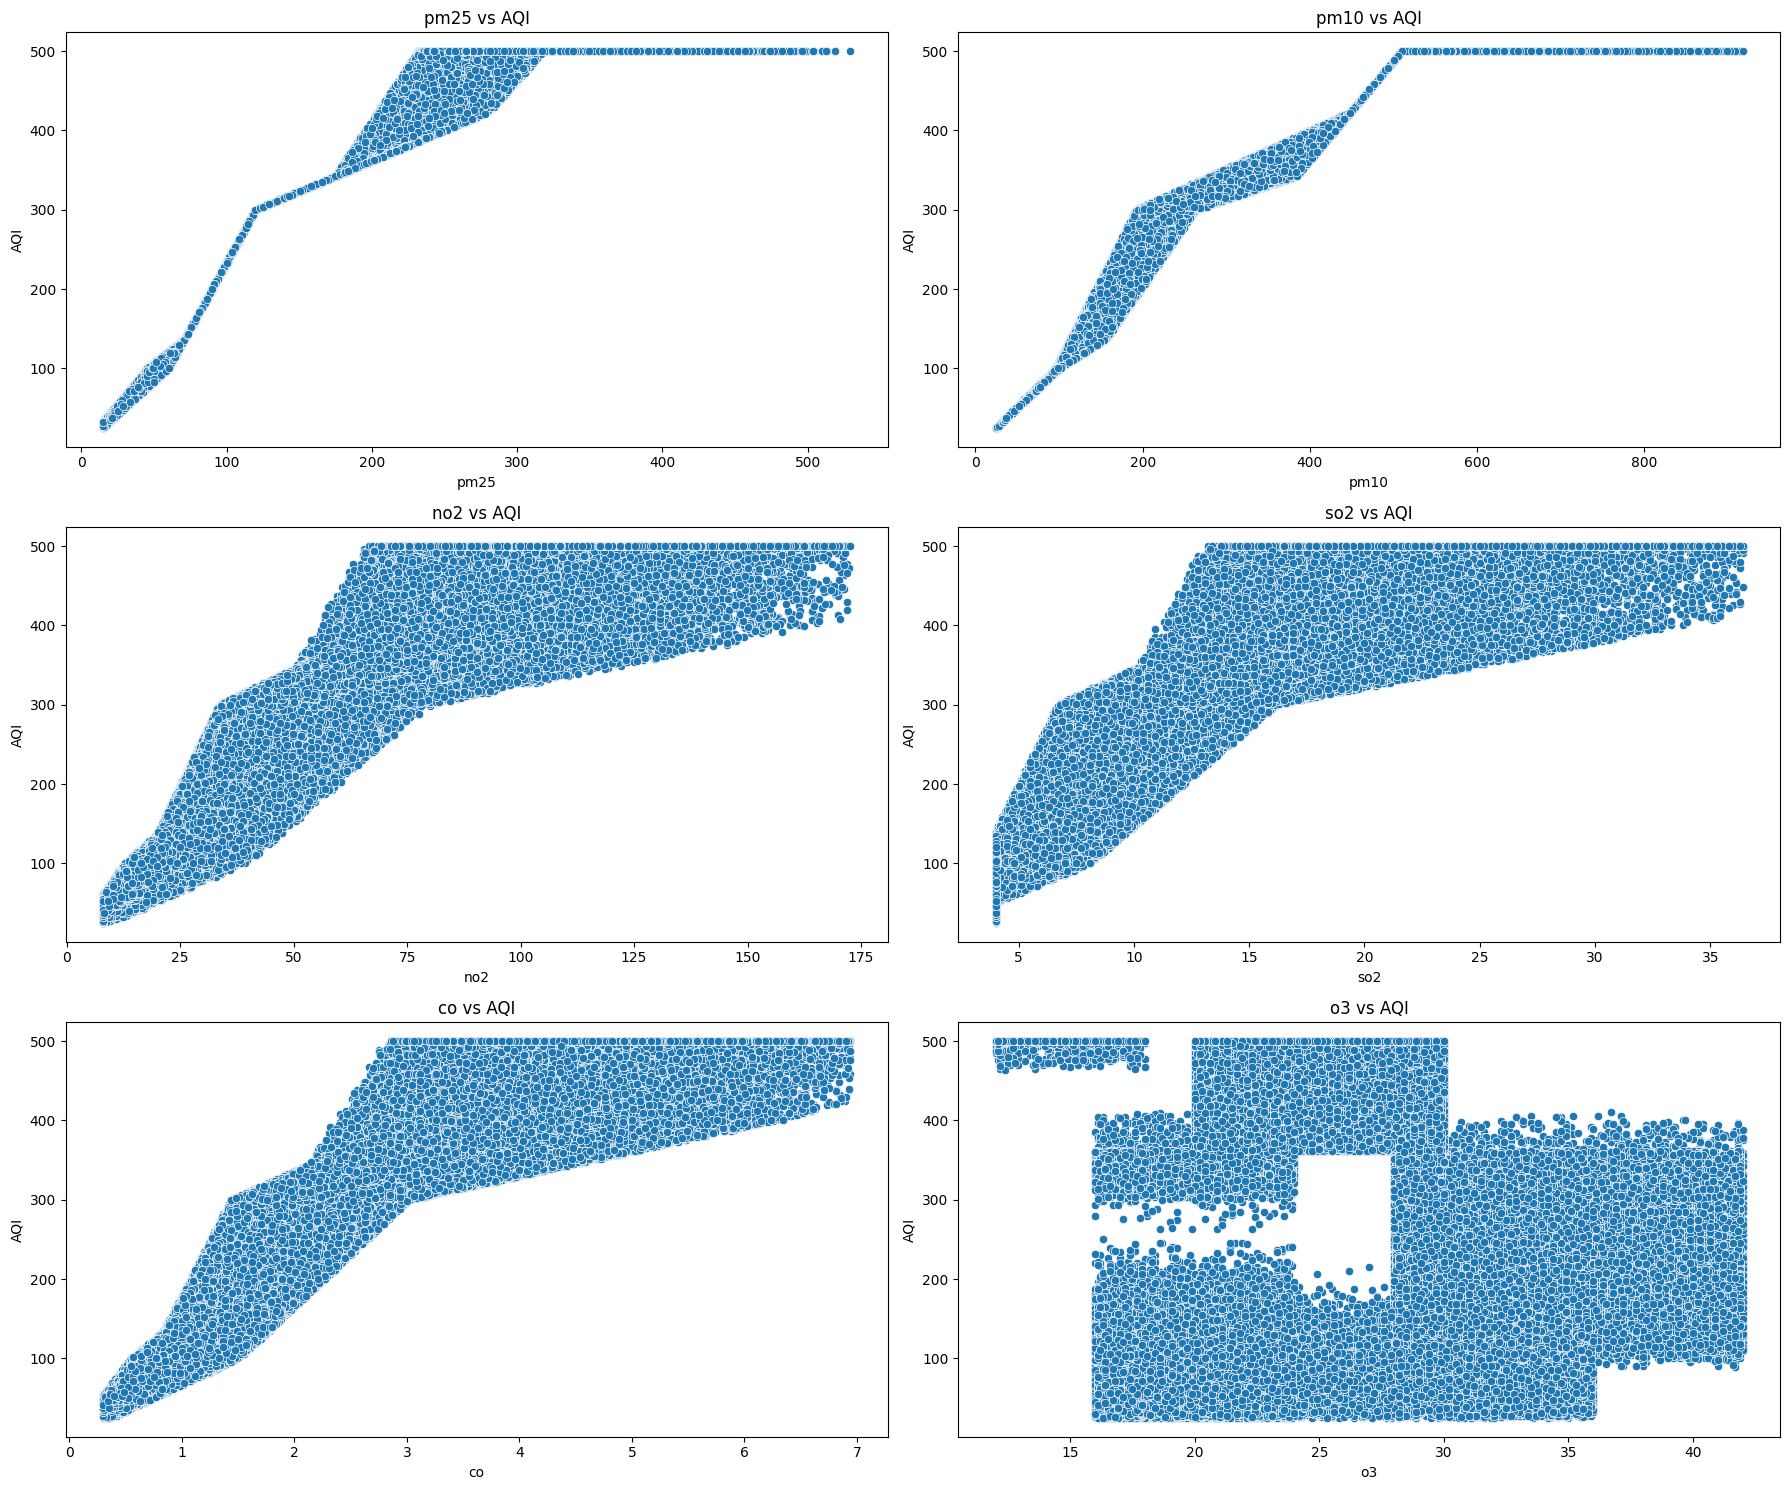

In [585]:
pollution_features = ["pm25","pm10","no2","so2","co","o3"]

plt.figure(figsize=(18,15))

i = 1
for col in pollution_features:
    plt.subplot(3, 2, i)   # 2 rows, 3 columns
    sns.scatterplot(x=df[col], y=df["aqi"])
    plt.title(f"{col} vs AQI")
    plt.xlabel(col)
    plt.ylabel("AQI")
    i += 1

plt.tight_layout()
plt.show()

• PM25 and PM10 show the strongest positive relationship with AQI, indicating particulate matter is the main contributor to air pollution.

• NO₂ and SO₂ also increase with AQI, suggesting emissions from vehicles and industrial activities affect air quality.

• CO levels rise along with AQI, showing that combustion-related pollution contributes to higher pollution levels.

• O₃ shows a weaker and more scattered relationship with AQI, indicating its impact on AQI is less consistent compared to other pollutants

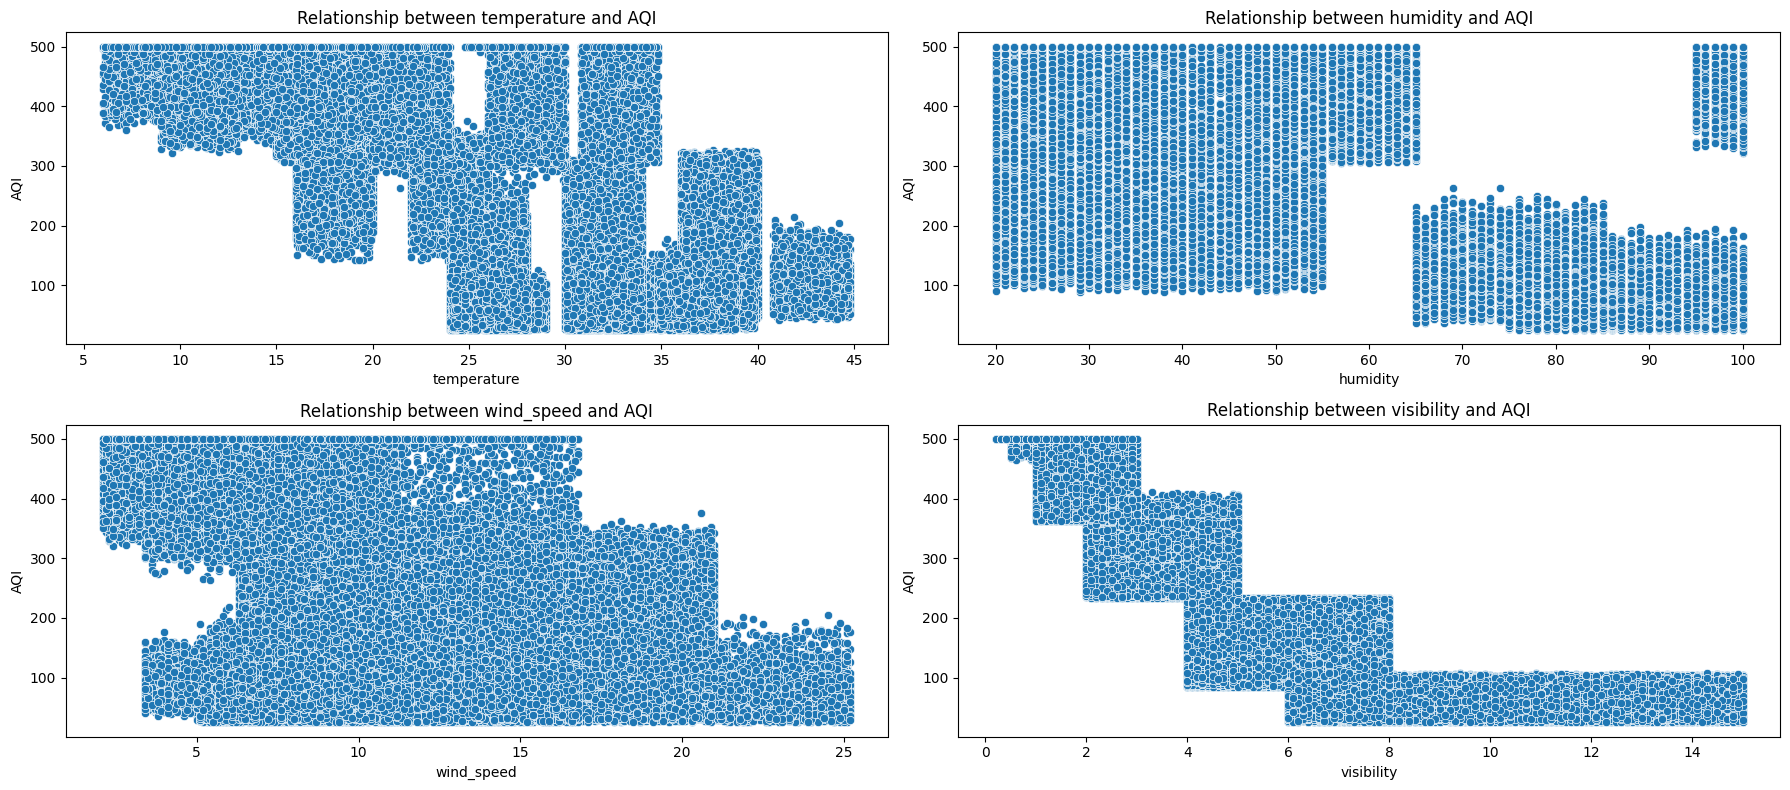

In [586]:
weather_features=["temperature","humidity","wind_speed","visibility"]
plt.figure(figsize=(18,8))
i=1
for columns in weather_features:
    plt.subplot(2,2,i)
    sns.scatterplot(x=df[columns],y=df["aqi"])
    plt.xlabel(columns)
    plt.ylabel("AQI")
    plt.title(f"Relationship between {columns} and AQI")
    i=i+1
plt.tight_layout()
plt.show()

• Temperature shows a weak relationship with AQI, indicating temperature alone does not strongly determine pollution levels.

• Humidity shows a slight effect on AQI, where higher humidity can sometimes correspond with increased pollution due to pollutant accumulation.

• Wind speed tends to reduce AQI, suggesting stronger winds help disperse pollutants and improve air quality.

• Visibility decreases as AQI increases, indicating poorer air quality leads to reduced atmospheric visibility.

## Time Features Vs AQI

In [587]:
month_map = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
df["month_name"] = df["month"].map(month_map)

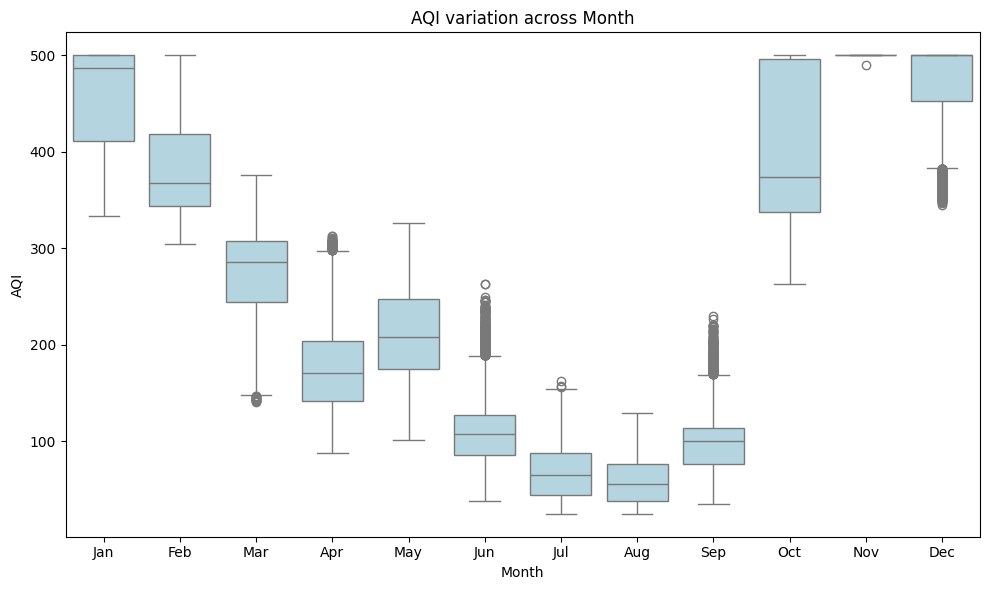

In [588]:
plt.figure(figsize=(10,6))
sns.boxplot(x=df["month_name"],y=df["aqi"],color="lightblue")
plt.xlabel("Month")
plt.ylabel("AQI")
plt.title(f"AQI variation across Month")
plt.tight_layout()
plt.show()

The boxplot shows that AQI is highest during winter months (October–January), indicating severe pollution. AQI gradually decreases towards summer and reaches the lowest levels during monsoon months (July–August). After September, pollution levels start increasing again. The presence of outliers suggests occasional extreme pollution events.

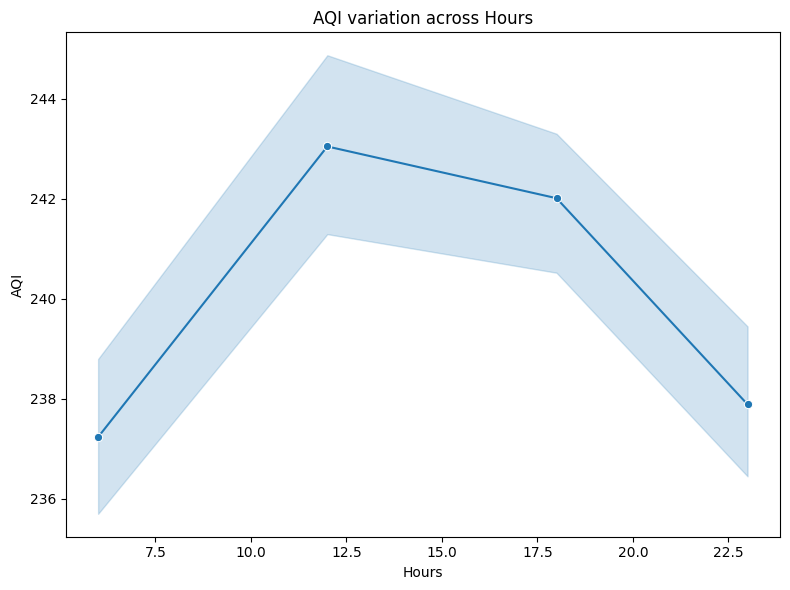

In [589]:
plt.figure(figsize=(8,6))
sns.lineplot(x=df["hour"],y=df["aqi"],marker="o")
plt.xlabel("Hours")
plt.ylabel("AQI")
plt.title(f"AQI variation across Hours")
plt.tight_layout()
plt.show()

The line plot shows that AQI gradually increases from early morning and reaches its peak around midday. After the afternoon, AQI begins to decrease slightly towards the evening and night. This indicates that pollution levels are relatively higher during the middle of the day compared to early morning and late night.


## Correlation Analysis



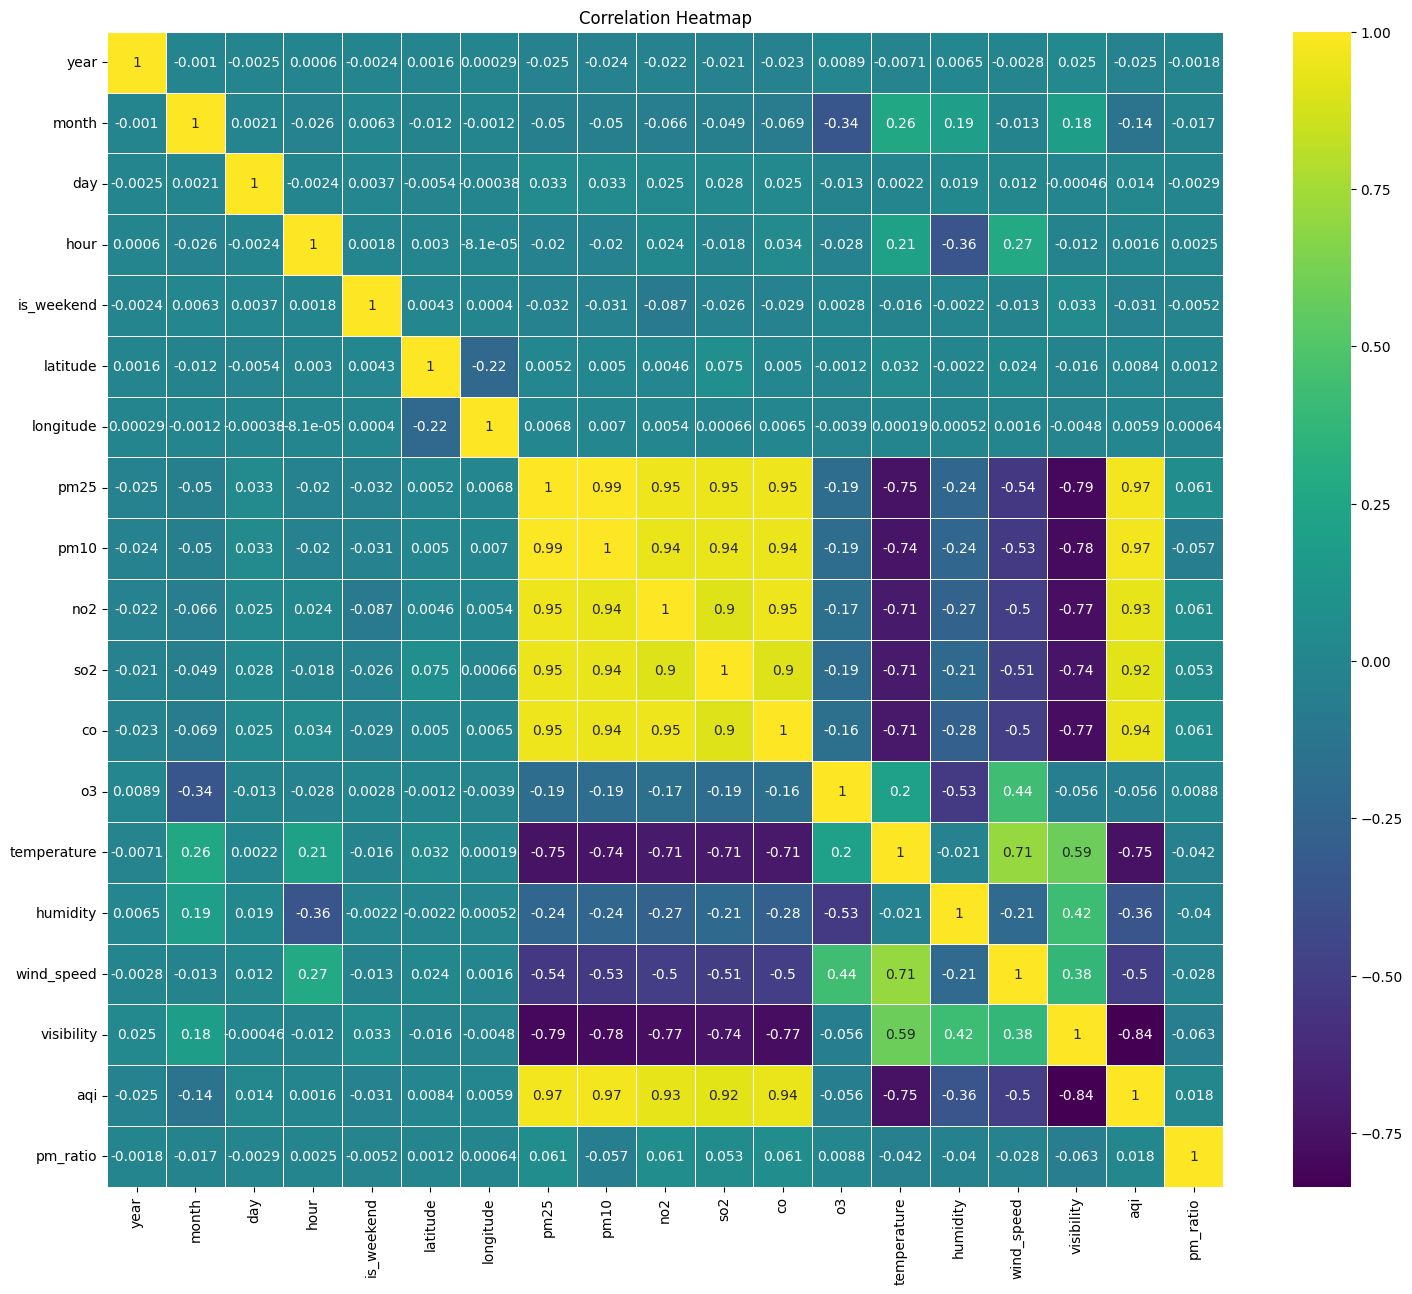

In [590]:
correlation_matrix=df.corr(numeric_only=True)
plt.figure(figsize=(18,15))
sns.heatmap(correlation_matrix,annot=True,cmap="viridis",linewidth=0.5)
plt.title("Correlation Heatmap")
plt.show()

## Key Findings from Exploratory Data Analysis

PM25 and PM10 strongly influence AQI

Winter months show higher pollution

Weather variables influence pollutant dispersion

AQI varies across hours of the day

## 🤖 Machine Learning Model Development

In [591]:
df = pd.get_dummies(df, columns=["season", "month_name","day_of_week"], drop_first=True)

In [592]:
x=df.drop("aqi",axis=1)
y=df["aqi"]

### Train-Test Split

In [593]:
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=42)

In [594]:
x_train.shape,x_test.shape

((131687, 38), (32922, 38))

In [595]:
x_train.select_dtypes(include="object").columns

Index([], dtype='object')

In [596]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [597]:
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.fit_transform(x_test)

### Model Training – Linear Regression

In [598]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train_scaled,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Model Prediction

In [599]:
y_predict=model.predict(x_test_scaled)

### Model Evaluation

In [600]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mae=mean_absolute_error(y_test,y_predict)
mse=mean_squared_error(y_test,y_predict)
rmse=np.sqrt(mse)
r2score=r2_score(y_test,y_predict)
print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)
print("R2SCORE:",r2score)

MAE: 16.414950005484897
MSE: 497.5399192554363
RMSE: 22.30560286689056
R2SCORE: 0.9809909537384176



• MAE = 16.41
On average, the model prediction is about 16 AQI units away from the actual value.

• MSE = 497.54
This shows the average squared prediction error of the model. It indicates the overall magnitude of prediction errors during evaluation

• RMSE = 22.30
Some predictions may have larger errors around 22 AQI units.

• R² Score = 0.98
The model explains about 98% of the AQI pattern, which means it learned the relationship between features and AQI very well.


### Actual vs Predicted AQI

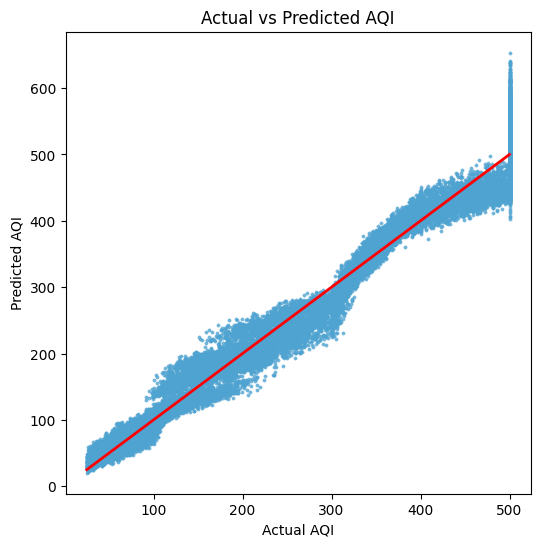

In [601]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_predict,s=6,color="#4FA3D1", alpha=0.8,edgecolor=None)
# perfect prediction line
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],color="red", linestyle="-",linewidth=2)
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI")
plt.show()

• The graph compares actual AQI values and predicted AQI values from the model.

• Most of the points are close to the red reference line, which means the predicted values are very close to the actual AQI values.

• This shows that the model has learned the relationship between the features and AQI well.

• Only a few points are slightly away from the line, indicating small prediction errors.

• Overall, the graph shows that the model predictions follow the actual AQI trend closely and the model performs well.

### Residual Analysis

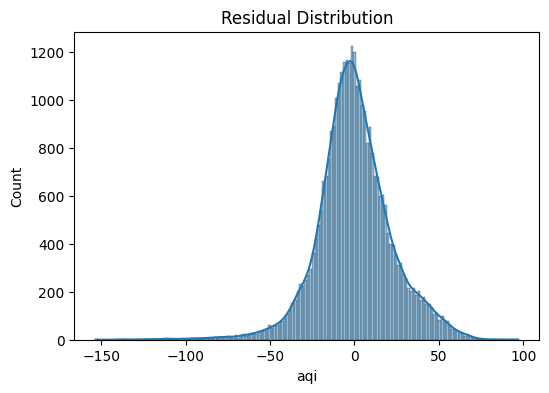

In [602]:
residuals=y_test-y_predict
plt.figure(figsize=(6,4))
sns.histplot(residuals,kde=True)
plt.title("Residual Distribution")
plt.show()

• The residual plot shows the difference between actual AQI and predicted AQI values.

• Most of the residual values are centered around zero, which means the model predictions are generally close to the actual AQI values.

• The distribution looks approximately symmetric, indicating that the model does not consistently overpredict or underpredict AQI.

• Only a small number of residuals appear far from zero, suggesting few larger prediction errors.

• Overall, the residual distribution indicates that the model fits the data reasonably well and predictions are mostly accurate.

In [603]:
coefficients = pd.DataFrame({"Feature": x.columns,"Coefficient": model.coef_})
# sort by importance
coefficients = coefficients.sort_values(by="Coefficient", key=abs, ascending=False)
# take top 10 most important
top_features = coefficients.head(10)

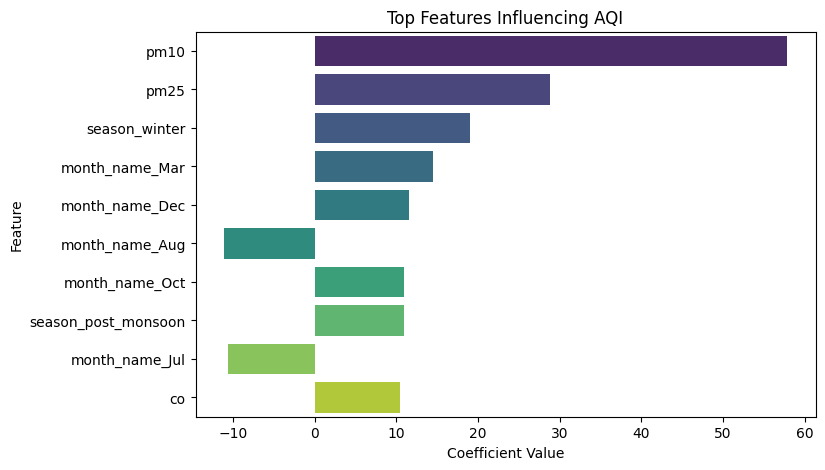

In [604]:
plt.figure(figsize=(8,5))
sns.barplot(x="Coefficient",y="Feature",data=top_features,palette="viridis")
plt.title("Top Features Influencing AQI")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.savefig("Topfeatures influencing AQI.png", dpi=300, bbox_inches="tight")
plt.show()

• PM10 has the highest influence on AQI, indicating that higher PM10 concentrations significantly increase air pollution levels.

• PM25 is the second most influential feature, showing that fine particulate matter strongly contributes to higher AQI values.

• Seasonal factors such as winter also affect AQI, suggesting that pollution levels tend to increase during colder months.

• Certain months like March and December show noticeable influence, indicating that air quality changes across different times of the year.

• Carbon monoxide (CO) also contributes to AQI, though its impact is smaller compared to particulate pollutants.

• Overall, the results show that particulate pollutants (PM10 and PM2.5) are the most important factors affecting air quality, while seasonal and temporal features provide additional influence.

## Conclusion

This project developed a machine learning model to predict the Air Quality Index (AQI) using pollutant concentrations, weather conditions, and temporal features. Exploratory Data Analysis revealed strong relationships between particulate pollutants such as PM10 and PM2.5 and AQI levels. Seasonal and monthly patterns also showed noticeable influence on air quality.

A Linear Regression model was trained using the processed dataset, and the model demonstrated strong predictive performance with an R² score of approximately 0.98. Evaluation metrics such as MAE and RMSE indicate that the model predictions are reasonably accurate and closely follow the actual AQI values.

Feature importance analysis highlights that particulate pollutants are the most significant contributors to AQI, while seasonal factors provide additional context to pollution patterns. Overall, the results show that machine learning techniques can effectively model and predict air quality levels based on environmental data.